In [4]:
import pandas as pd
import random

random.seed(42)

# -------- configuration --------
target_events = 100

doc_types = ["Deviation", "CAPA", "SOP", "ChangeControl"]
doc_type_weights = [0.4, 0.3, 0.2, 0.1]

review_roles = ["QC", "QA", "RA"]

comment_categories = [
    "missing_information",
    "wording",
    "compliance_concern",
    "inconsistency",
    "formatting",
    "evidence_gap",
    "cross_reference_issue",
    "unclear_responsibility"
]

category_weights = [0.25, 0.20, 0.18, 0.15, 0.10, 0.07, 0.03, 0.02]

severity_levels = ["minor", "moderate", "major"]
severity_weights = [0.5, 0.35, 0.15]

revision_types = ["wording", "data", "structure", "regulatory"]

turnaround = {
    "QC": (1, 2),
    "QA": (1, 3),
    "RA": (2, 5)
}

# -------- generation --------
rows = []
event_id = 1
doc_id = 1

while len(rows) < target_events:
    case_id = f"D{str(doc_id).zfill(2)}"
    doc_type = random.choices(doc_types, weights=doc_type_weights)[0]

    # more realistic round counts
    if doc_type in ["Deviation", "CAPA"]:
        rounds = random.choice([3, 4, 5])
    elif doc_type == "SOP":
        rounds = random.choice([2, 3, 4])
    else:
        rounds = random.choice([2, 3])

    draft_version = 1

    for r in range(1, rounds + 1):
        if len(rows) >= target_events:
            break

        role = review_roles[min(r - 1, len(review_roles) - 1)]
        reviewer = f"{role}{random.randint(1,3):02d}"

        category = random.choices(comment_categories, weights=category_weights)[0]
        severity = random.choices(severity_levels, weights=severity_weights)[0]
        revision = random.choice(revision_types)

        # 현실성 보정: round가 뒤로 갈수록 resolve 확률 높음
        if r == 1:
            resolved = random.choices(["yes", "no"], weights=[0.35, 0.65])[0]
        elif r == 2:
            resolved = random.choices(["yes", "no"], weights=[0.55, 0.45])[0]
        else:
            resolved = random.choices(["yes", "no"], weights=[0.75, 0.25])[0]

        reopened = "yes" if resolved == "no" else "no"
        days = random.randint(*turnaround[role])

        comment = category.replace("_", " ")

        rows.append({
            "EventID": f"E{str(event_id).zfill(3)}",
            "CaseID": case_id,
            "DocType": doc_type,
            "DraftVersion": f"v{draft_version}",
            "ReviewRound": r,
            "ReviewerRole": role,
            "ReviewerID": reviewer,
            "CommentCategory": category,
            "Severity": severity,
            "RevisionType": revision,
            "ResolvedNextRound": resolved,
            "Reopened": reopened,
            "DaysToReturn": days,
            "CommentTextShort": comment,
            "Notes": ""
        })

        event_id += 1
        draft_version += 1

    doc_id += 1

df = pd.DataFrame(rows)

# -------- save --------
file_name = "review_workflow_dataset_100.xlsx"
df.to_excel(file_name, index=False)

print("Dataset created:", file_name)
print("Total events:", len(df))
print("Total documents:", df['CaseID'].nunique())

Dataset created: review_workflow_dataset_100.xlsx
Total events: 100
Total documents: 31


Total events: 100
Total documents: 31


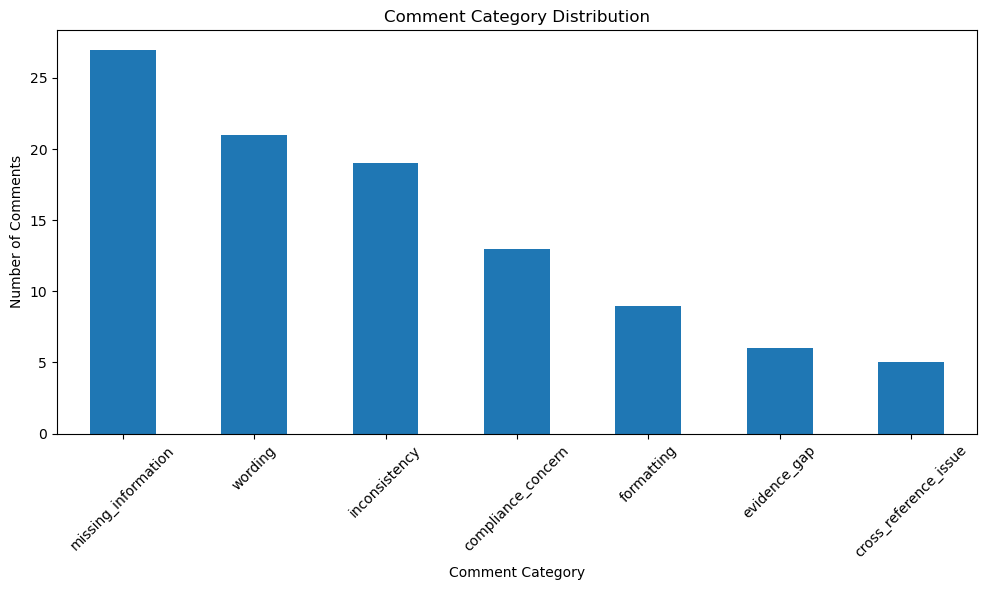

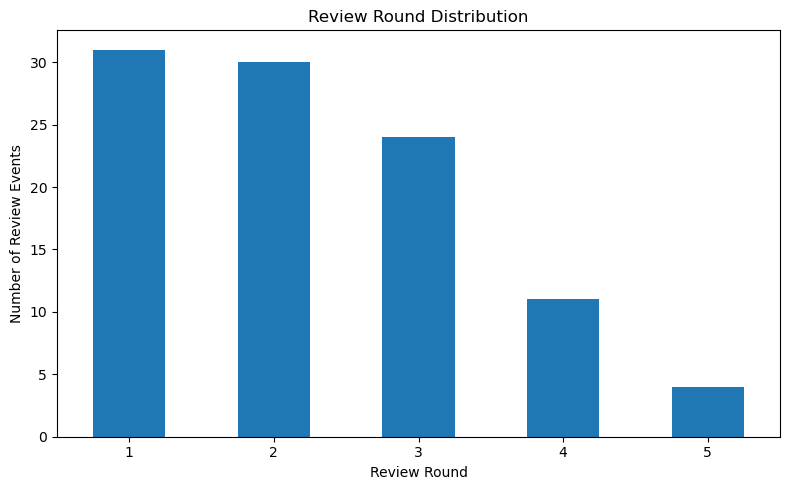

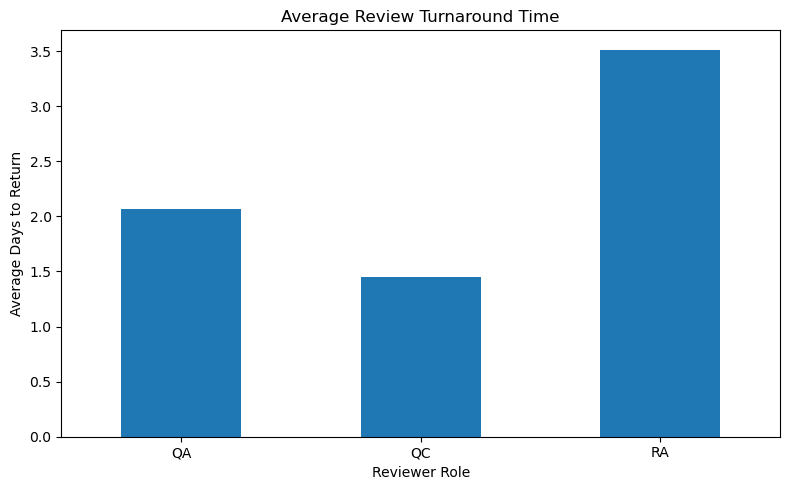

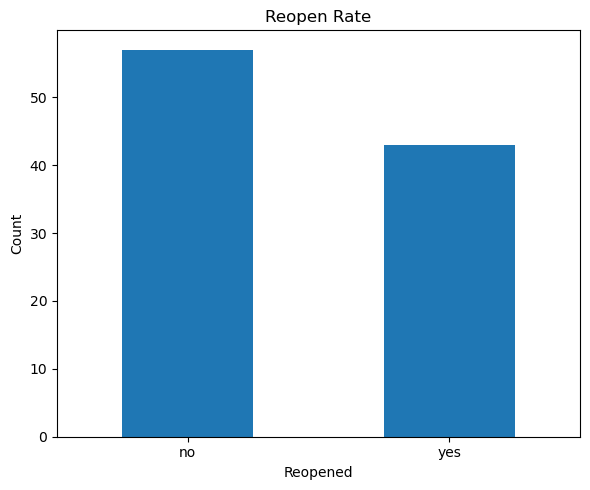


Category distribution:
CommentCategory
missing_information      27
wording                  21
inconsistency            19
compliance_concern       13
formatting                9
evidence_gap              6
cross_reference_issue     5
Name: count, dtype: int64

Round distribution:
ReviewRound
1    31
2    30
3    24
4    11
5     4
Name: count, dtype: int64

Reviewer turnaround:
ReviewerRole
QA    2.07
QC    1.45
RA    3.51
Name: DaysToReturn, dtype: float64

Reopen rate: 43.0 %


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# load dataset
# ---------------------------

file_name = "review_workflow_dataset_100.xlsx"
df = pd.read_excel(file_name)

print("Total events:", len(df))
print("Total documents:", df["CaseID"].nunique())

# ---------------------------
# basic cleaning
# ---------------------------

df["ReviewRound"] = pd.to_numeric(df["ReviewRound"], errors="coerce")
df["DaysToReturn"] = pd.to_numeric(df["DaysToReturn"], errors="coerce")
df["Reopened"] = df["Reopened"].astype(str).str.lower().str.strip()

# ---------------------------
# 1. Comment Category Distribution
# ---------------------------

category_counts = df["CommentCategory"].value_counts()

plt.figure(figsize=(10,6))
category_counts.plot(kind="bar")

plt.title("Comment Category Distribution")
plt.xlabel("Comment Category")
plt.ylabel("Number of Comments")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("figure_1_category_distribution.png", dpi=300)

plt.show()

# ---------------------------
# 2. Review Round Distribution
# ---------------------------

round_counts = df["ReviewRound"].value_counts().sort_index()

plt.figure(figsize=(8,5))
round_counts.plot(kind="bar")

plt.title("Review Round Distribution")
plt.xlabel("Review Round")
plt.ylabel("Number of Review Events")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("figure_2_round_distribution.png", dpi=300)

plt.show()

# ---------------------------
# 3. Reviewer Turnaround Time
# ---------------------------

turnaround = df.groupby("ReviewerRole")["DaysToReturn"].mean()

plt.figure(figsize=(8,5))
turnaround.plot(kind="bar")

plt.title("Average Review Turnaround Time")
plt.xlabel("Reviewer Role")
plt.ylabel("Average Days to Return")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("figure_3_reviewer_turnaround.png", dpi=300)

plt.show()

# ---------------------------
# 4. Reopen Rate
# ---------------------------

reopen_counts = df["Reopened"].value_counts()

plt.figure(figsize=(6,5))
reopen_counts.plot(kind="bar")

plt.title("Reopen Rate")
plt.xlabel("Reopened")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("figure_4_reopen_rate.png", dpi=300)

plt.show()

# ---------------------------
# quick stats
# ---------------------------

print("\nCategory distribution:")
print(category_counts)

print("\nRound distribution:")
print(round_counts)

print("\nReviewer turnaround:")
print(turnaround.round(2))

reopen_rate = (df["Reopened"] == "yes").mean() * 100
print("\nReopen rate:", round(reopen_rate,2), "%")

In [ ]:
!streamlit run review_dashboard.py

In [7]:
import os
os.listdir()

['.anaconda',
 '.claude.json',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.streamlit',
 '01_SOP_OCR_pipeline.ipynb.ipynb',
 'anaconda3',
 'anaconda_projects',
 'app.py',
 'AppData',
 'Application Data',
 'backup',
 'CF_corpus500_annotation.ipynb.ipynb',
 'cf_sentences.xlsx',
 'cf_sentences_coded.xlsx',
 'cf_sentences_recoded_full.xlsx',
 'cf_sentence_coding.ipynb',
 'cf_sentence_codingㅎ.ipynb',
 'Contacts',
 'Cookies',
 'daily_reports',
 'daily_reports_report_2025-10-26.txt',
 'data.txt',
 'data_backup',
 'Desktop',
 'df_elisa.csv',
 'diary.text',
 'Documents',
 'Downloads',
 'elisa_plate_stats.csv',
 'fake_omics_data.csv',
 'Favorites',
 'Figure1_Friction_Distribution.png',
 'figure_1_category_distribution.png',
 'figure_2_round_distribution.png',
 'figure_3_reviewer_turnaround.png',
 'figure_4_reopen_rate.png',
 'hci_user_behavior.csv',
 'IntelGraphicsProfiles',
 'keyword_index.csv',
 'Links',
 'Local Settings',
 'log.txt